<a href="https://colab.research.google.com/github/owlmt/QuantumSecurity/blob/main/Grover_Hash_Collision_BHT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finding a Hash Collision with Grover (BHT-style) on Aer

Third in the symmetric-crypto set. The earlier [notebook](https://github.com/owlmt/QuantumSecurity/blob/main/Grover_Toy_AES_KeySearch.ipynb) did a **preimage/key search**; this one
finds a **collision** — two distinct inputs $x_0 \neq x$ with $H(x_0)=H(x)$ — by using Grover to
amplify the preimages of an anchor's digest. We use a real *compressing* toy hash
($10\text{ bits}\to 6\text{ bits}$), so collisions are guaranteed to exist by the pigeonhole principle.

## ⚠️ Honest framing: collisions are the *weakest* quantum win

Quantum collision finding (the **BHT** algorithm, Brassard–Høyer–Tapp) reaches only
$O(2^{n/3})$ for an $n$-bit digest, versus the classical birthday bound $O(2^{n/2})$. That is an
even *smaller* edge than Grover's quadratic preimage speedup — and worse, BHT needs $\sim2^{n/3}$
**quantum memory (QRAM)**, so against parallel classical collision search (van Oorschot–Wiener) it
offers little to no practical advantage. Concretely:

| Target | digest bits | classical birthday | quantum BHT | on Aer? |
|---|---|---|---|---|
| this toy | 6 | $2^{3}$ | $2^{2}$ | yes |
| SHA-1 (generic) | 160 | $2^{80}$ | $2^{53}$ | no |
| SHA-256 | 256 | $2^{128}$ | $2^{85}$ | no |

The toy below shows the *mechanism* and gives **zero** capability against any real hash.

In [7]:
# Colab setup
!pip install -q qiskit qiskit-aer pylatexenc

## 1. A compressing toy hash $H:\{0,1\}^{10}\to\{0,1\}^{6}$

Built from a random 6-bit S-box (nonlinearity), a rotation (diffusion), and XOR-folding of the
input bits. Because 10 input bits map to 6 output bits, every digest has on average
$2^{10-6}=16$ preimages — so collisions are unavoidable.

In [8]:
import numpy as np, math, time
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate, ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from collections import defaultdict

M_IN, N_OUT = 10, 6
rng = np.random.default_rng(7)
SBOX = list(rng.permutation(2**N_OUT))            # random invertible 6-bit S-box
def rotl(v, n=N_OUT): return ((v<<1)|(v>>(n-1))) & (2**n-1)

def H(x):
    xL = x & 0x3F; xH = (x >> 6) & 0xF
    o = SBOX[xL]
    o = SBOX[o ^ xH]
    o = rotl(o)
    o = SBOX[o ^ (xL & 0xF)]
    return o

# pick an anchor whose digest has several preimages -> guaranteed collisions
buckets = defaultdict(list)
for x in range(2**M_IN): buckets[H(x)].append(x)
x0 = next(x for x in range(2**M_IN) if len(buckets[H(x)]) >= 4)
d0 = H(x0)
collisions = [x for x in buckets[d0] if x != x0]
print(f"H : {M_IN}-bit input  ->  {N_OUT}-bit digest")
print(f"anchor      x0 = {x0:0{M_IN}b}   digest H(x0) = {d0:0{N_OUT}b} ({d0})")
print(f"preimages of this digest: {len(buckets[d0])}  ->  {len(collisions)} collisions with x0")
print(f"a few collisions: {[f'{x:0{M_IN}b}' for x in collisions[:6]]}")

H : 10-bit input  ->  6-bit digest
anchor      x0 = 0000000000   digest H(x0) = 101111 (47)
preimages of this digest: 15  ->  14 collisions with x0
a few collisions: ['0000010100', '0001000001', '0001111100', '0010010001', '0010101101', '0011010000']


## 2. Reversible quantum hash $(x,0)\mapsto(x,H(x))$ and a correctness check

The input is preserved and the digest written into a 6-qubit ancilla. S-box and rotation are
bijections → permutation gates; XOR-folds are `CX`. We confirm the circuit reproduces the
classical hash before using it in the oracle.

In [9]:
def perm_gate(table, label):
    Mx=np.zeros((2**N_OUT, 2**N_OUT))
    for v,o in enumerate(table): Mx[o,v]=1
    return UnitaryGate(Mx, label=label)
SG = perm_gate(SBOX, "S")
RG = perm_gate([rotl(v) for v in range(2**N_OUT)], "rot")

def hash_circuit(xin, out):
    c = QuantumCircuit(xin, out, name="H")
    for i in range(6): c.cx(xin[i], out[i])      # out = xL
    c.append(SG, out[:])                          # S
    for i in range(4): c.cx(xin[6+i], out[i])     # out ^= xH
    c.append(SG, out[:])                          # S
    c.append(RG, out[:])                          # rotate
    for i in range(4): c.cx(xin[i], out[i])       # out ^= (xL & 0xF)
    c.append(SG, out[:])                          # S
    return c

sim = AerSimulator()
xin=QuantumRegister(M_IN,'x'); out=QuantumRegister(N_OUT,'o')
ok = True
for xt in rng.choice(2**M_IN, 24, replace=False):
    t=QuantumCircuit(xin,out)
    for i in range(M_IN):
        if (int(xt)>>i)&1: t.x(xin[i])
    t.compose(hash_circuit(xin,out), inplace=True); t.save_statevector()
    sv=sim.run(t).result().get_statevector()
    oval=(int(np.argmax(np.abs(sv.data)))>>M_IN)&(2**N_OUT-1)
    ok &= (oval==H(int(xt)))
print("quantum hash matches classical on 24 random inputs:", ok)

quantum hash matches classical on 24 random inputs: True


## 3. The Grover collision oracle

To get a *distinct* second input we mark $\{x : H(x)=d_0\}$ and then **un-mark the anchor** $x_0$,
so Grover amplifies only genuine collisions:
1. compute $H(x)$ into the ancilla,
2. phase-flip where the digest equals $d_0$,
3. uncompute $H$,
4. phase-flip $x_0$ once more (cancelling its mark).

Then the diffuser reflects the input register about its mean.

marked collisions = 14, search space = 1024, Grover iterations = 7


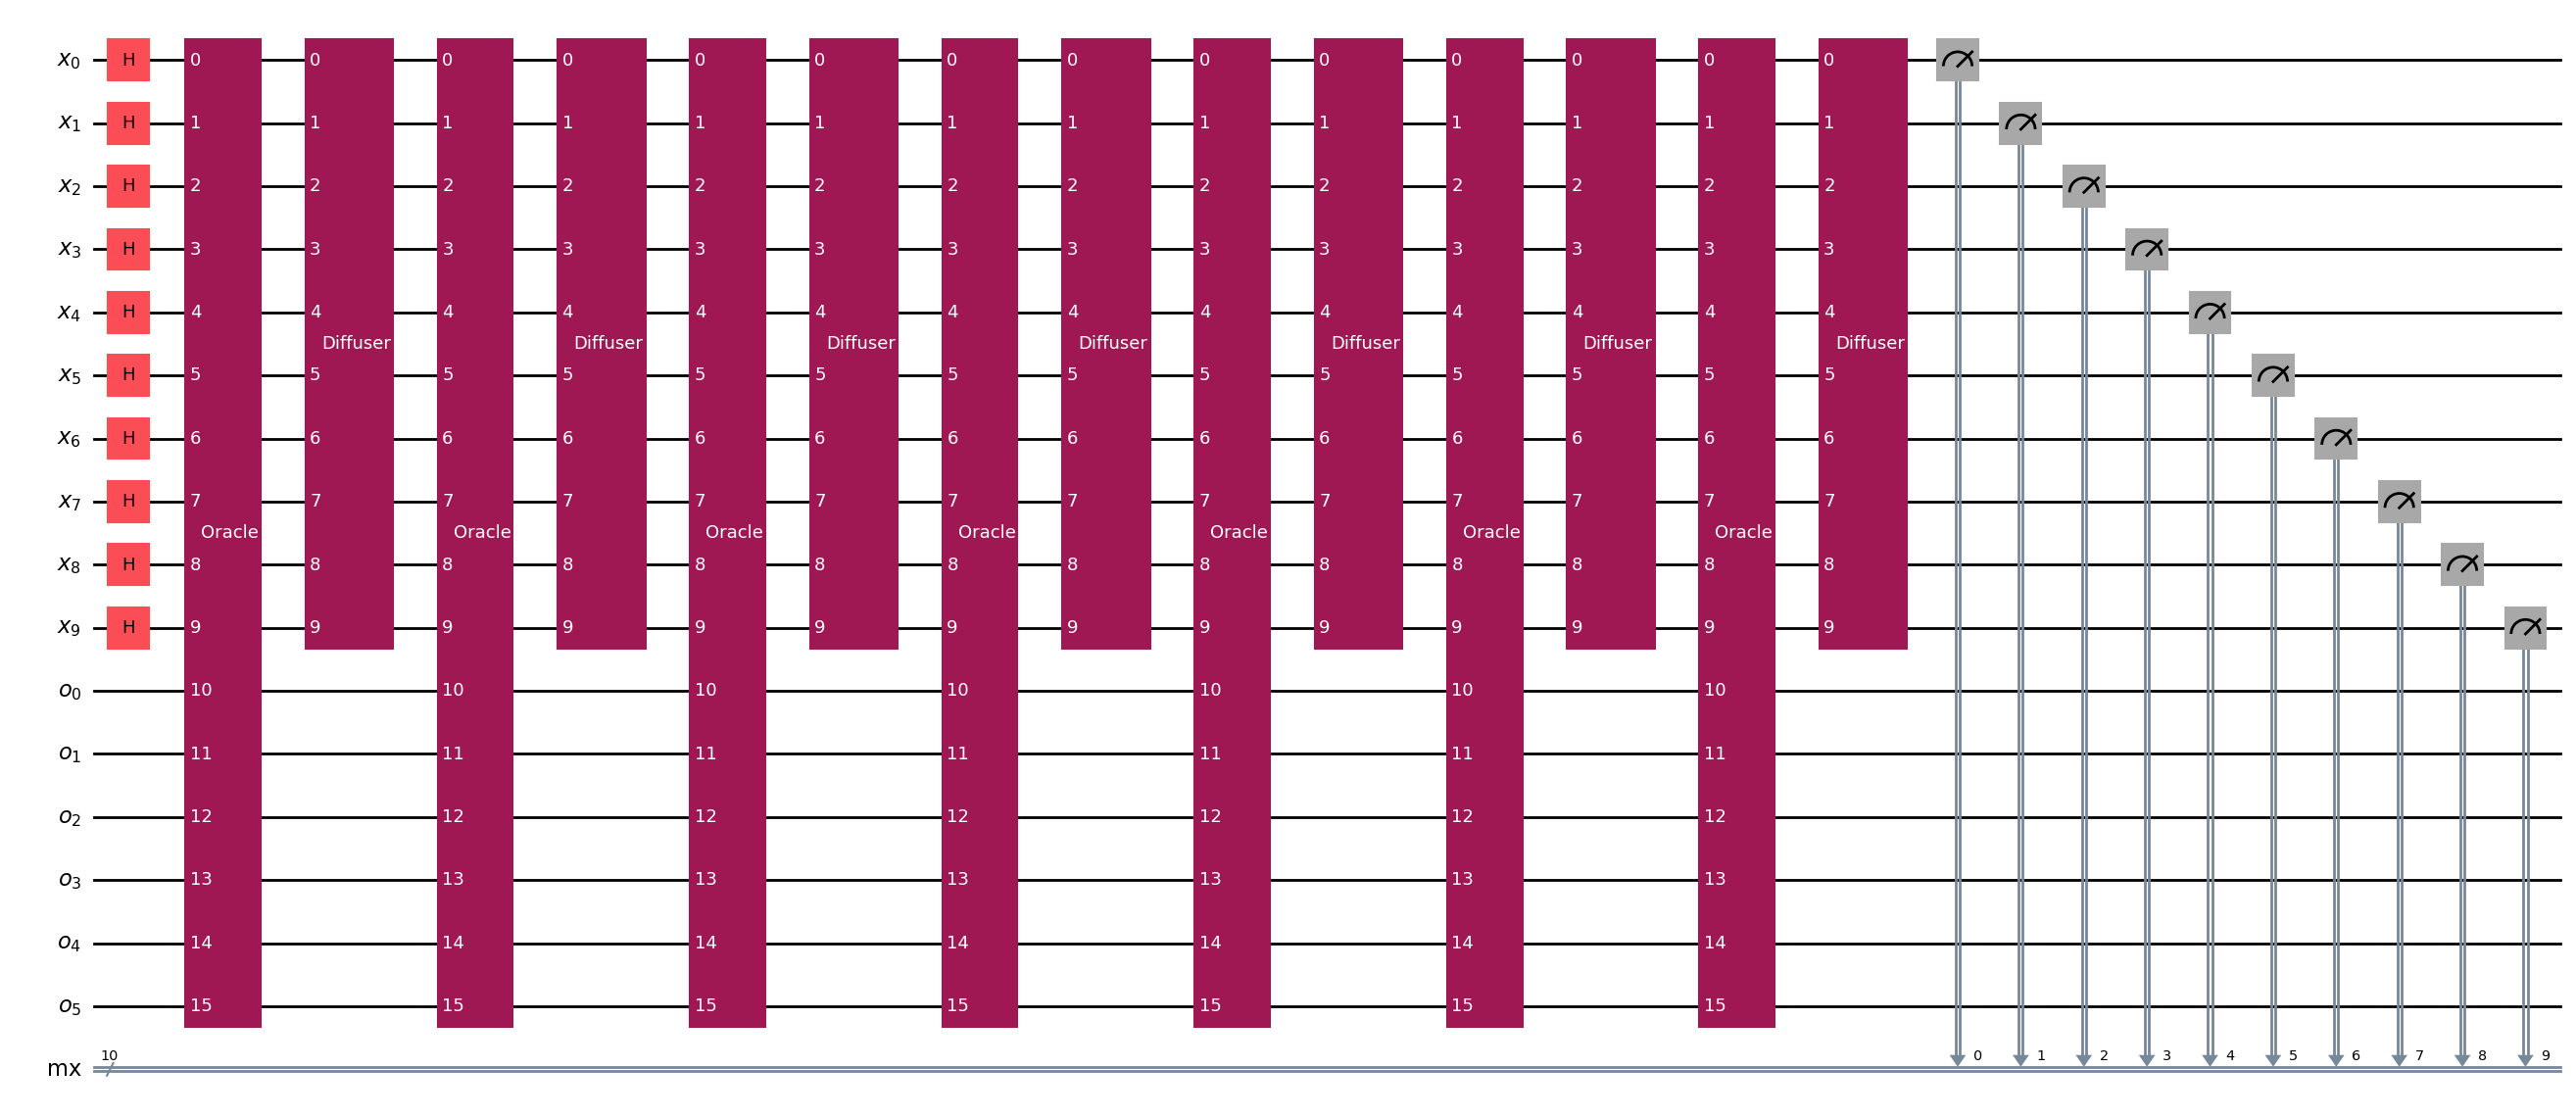

In [10]:
def mcz(c, qubits, value, width):       # phase-flip the basis state == value
    for i in range(width):
        if not ((value>>i)&1): c.x(qubits[i])
    c.append(ZGate().control(width-1), qubits[:])
    for i in range(width):
        if not ((value>>i)&1): c.x(qubits[i])

def oracle_gate():
    xin=QuantumRegister(M_IN,'x'); out=QuantumRegister(N_OUT,'o')
    c=QuantumCircuit(xin,out,name="Oracle")
    Hg=hash_circuit(xin,out).to_gate()
    c.append(Hg, xin[:]+out[:])
    mcz(c, out, d0, N_OUT)               # mark digest == d0
    c.append(Hg.inverse(), xin[:]+out[:])
    mcz(c, xin, x0, M_IN)               # un-mark the anchor x0
    return c

def diffuser_gate():
    xin=QuantumRegister(M_IN,'x'); c=QuantumCircuit(xin,name="Diffuser")
    c.h(xin); c.x(xin); c.append(ZGate().control(M_IN-1), xin[:]); c.x(xin); c.h(xin)
    return c

n_marked = len(collisions)
iters = round(math.pi/4*math.sqrt(2**M_IN / n_marked))
print(f"marked collisions = {n_marked}, search space = {2**M_IN}, Grover iterations = {iters}")

xin=QuantumRegister(M_IN,'x'); out=QuantumRegister(N_OUT,'o'); cl=ClassicalRegister(M_IN,'mx')
qc=QuantumCircuit(xin,out,cl)
qc.h(xin)
O=oracle_gate().to_gate(); D=diffuser_gate().to_gate()
for _ in range(iters):
    qc.append(O, xin[:]+out[:]); qc.append(D, xin[:])
qc.measure(xin, cl)
qc.draw('mpl', fold=-1)

## 4. Run on Aer and read off the collision

CX=196  depth=156
P(valid collision) = 0.967     P(anchor x0, excluded) = 0.000

top measured inputs:
  x=0111110001 ( 497)   H(x)=101111   p=0.078   COLLISION with x0
  x=0100011101 ( 285)   H(x)=101111   p=0.076   COLLISION with x0
  x=1001001010 ( 586)   H(x)=101111   p=0.072   COLLISION with x0
  x=0010101101 ( 173)   H(x)=101111   p=0.072   COLLISION with x0
  x=0000010100 (  20)   H(x)=101111   p=0.071   COLLISION with x0
  x=0100100010 ( 290)   H(x)=101111   p=0.070   COLLISION with x0

COLLISION FOUND:
  x0 = 0000000000  ->  H = 101111
  x  = 0111110001  ->  H = 101111
  distinct inputs, identical digest:  True


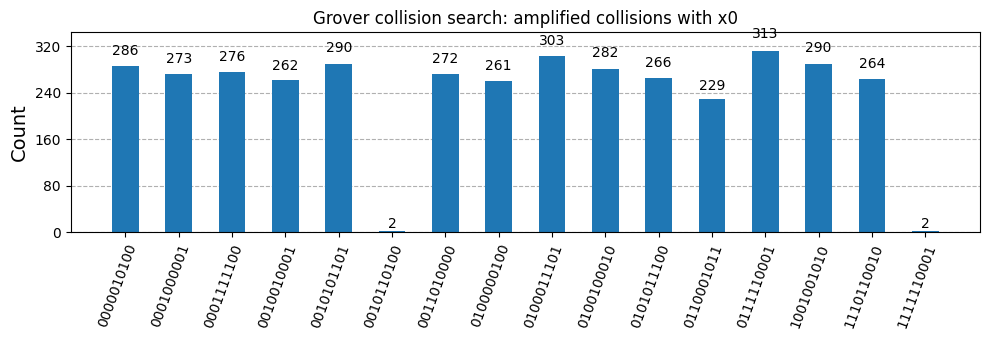

In [11]:
tqc = transpile(qc, sim)
counts = sim.run(tqc, shots=4000).result().get_counts()
tot = sum(counts.values())

# success = probability the measured input is a genuine collision with x0
valid  = sum(c for bs,c in counts.items() if H(int(bs,2))==d0 and int(bs,2)!=x0)
anchor = sum(c for bs,c in counts.items() if int(bs,2)==x0)
print(f"CX={tqc.count_ops().get('cx',0)}  depth={tqc.depth()}")
print(f"P(valid collision) = {valid/tot:.3f}     P(anchor x0, excluded) = {anchor/tot:.3f}\n")

print("top measured inputs:")
for bs,c in sorted(counts.items(), key=lambda kv:-kv[1])[:6]:
    x=int(bs,2)
    tag = 'COLLISION with x0' if (H(x)==d0 and x!=x0) else ''
    print(f"  x={bs} ({x:>4})   H(x)={H(x):0{N_OUT}b}   p={c/tot:.3f}   {tag}")

x_found = int(max(counts, key=counts.get), 2)
print(f"\nCOLLISION FOUND:")
print(f"  x0 = {x0:0{M_IN}b}  ->  H = {H(x0):0{N_OUT}b}")
print(f"  x  = {x_found:0{M_IN}b}  ->  H = {H(x_found):0{N_OUT}b}")
print(f"  distinct inputs, identical digest:  {x0 != x_found and H(x0)==H(x_found)}")
plot_histogram({k:v for k,v in sorted(counts.items(),key=lambda kv:-kv[1])[:16]},
               figsize=(10,3.5), title='Grover collision search: amplified collisions with x0')

## 5. BHT and the scaling reality

The anchor approach above is the heart of the full **BHT** algorithm: BHT builds a *table* of
$t\approx2^{n/3}$ anchors classically, then Grover-searches for any input colliding with the
table. Balancing the classical table cost against the quantum search gives the famous
$O(2^{n/3})$ runtime.

In [12]:
import math
print(f"{'target':18s}{'digest bits':>12}{'classical 2^(n/2)':>20}{'BHT 2^(n/3)':>15}{'feasible':>11}")
for name, n in [("toy hash", 6), ("SHA-1 (generic)", 160), ("SHA-256", 256), ("SHA-512", 512)]:
    feasible = "yes" if n <= 16 else "NO"
    print(f"{name:18s}{n:>12}{('2^%d'%(n//2)):>20}{('2^%d'%(n//3)):>15}{feasible:>11}")
print("\nTwo reasons real hashes stay safe against quantum collision search:")
print(" 1. 2^(n/3) is still astronomical: SHA-256 -> ~2^85 hash circuits, fault-tolerant.")
print(" 2. BHT needs ~2^(n/3) quantum RAM; without it, classical parallel collision")
print("    search (van Oorschot-Wiener) is competitive, so the quantum edge largely vanishes.")

target             digest bits   classical 2^(n/2)    BHT 2^(n/3)   feasible
toy hash                     6                 2^3            2^2        yes
SHA-1 (generic)            160                2^80           2^53         NO
SHA-256                    256               2^128           2^85         NO
SHA-512                    512               2^256          2^170         NO

Two reasons real hashes stay safe against quantum collision search:
 1. 2^(n/3) is still astronomical: SHA-256 -> ~2^85 hash circuits, fault-tolerant.
 2. BHT needs ~2^(n/3) quantum RAM; without it, classical parallel collision
    search (van Oorschot-Wiener) is competitive, so the quantum edge largely vanishes.


### Notes

- **Why it's honestly a collision.** $H$ is a real compressing function; Grover is never told the
  collisions — it amplifies whichever inputs share the anchor's digest. The only thing computed
  classically is the anchor's digest $d_0$ (and, for parameter-setting/verification, the preimage
  count — which a real attack estimates rather than enumerates).
- **Scaling wall.** This toy lives at ~16 qubits. Each extra digest bit roughly doubles the
  statevector; past ~26–28 qubits it no longer fits in memory — the same wall that keeps real
  hashes out of reach.
- **To experiment.** Change the seed for a different S-box, widen `M_IN`/`N_OUT`, or replace the
  single-anchor mark with a multi-anchor table to build the full BHT search.